# Exercise 3
## Action Recognition on KTH-Actions with RNNs

## Imports

In [1]:
import os
import time
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

## Config

In [2]:
DATA_ROOT   = Path("/home/nfs/data/hdd_datasets/kth_actions")
NUM_FRAMES  = 10
BATCH_SIZE  = 32
NUM_WORKERS = 4
NUM_EPOCHS  = 15
LR          = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch._dynamo.reset()

Using device: cuda


## KTH Dataset

The KTH Actions dataset contains 6 action classes performed by 25 subjects.
We split by person ID:
- **Train**: persons 1–16
- **Valid**: persons 17–20
- **Test**: persons 21–25

Each video is split into non-overlapping subsequences of `NUM_FRAMES` frames.

In [3]:
class KTHDataset(Dataset):
    """
    KTH Actions dataset loaded from pre-extracted 64x64 PNG frames.
    Videos are split into subsequences of num_frames frames with a given stride.
    Using stride < num_frames produces overlapping subsequences and more training data.
    Train/valid/test split is determined by person ID (25 subjects total).
    Set preload=True to cache all frames in RAM and avoid repeated disk reads.
    """

    CLASSES = ["boxing", "handclapping", "handwaving", "jogging", "running", "walking"]
    CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

    SPLIT_PERSONS = {
        "train": list(range(1, 17)),
        "valid": list(range(17, 21)),
        "test":  list(range(21, 26)),
    }

    def __init__(self, root, split="train", num_frames=10, stride=None, transform=None, preload=True):
        assert split in self.SPLIT_PERSONS
        self.num_frames = num_frames
        self.transform  = transform
        persons         = self.SPLIT_PERSONS[split]
        stride          = stride if stride is not None else num_frames   # default: non-overlapping

        processed_root = Path(root) / "processed"
        self.samples = []   # (sorted_frame_paths, start_idx, label)

        for cls in self.CLASSES:
            for video_dir in sorted((processed_root / cls).iterdir()):
                if not video_dir.is_dir():
                    continue
                stem = video_dir.name.split("_")[0].replace("person", "")
                if not stem.isdigit():
                    continue
                person_id = int(stem)
                if person_id not in persons:
                    continue
                frame_paths = sorted(video_dir.glob("*.png"))
                n = len(frame_paths)
                if n < num_frames:
                    continue
                label = self.CLASS_TO_IDX[cls]
                for start in range(0, n - num_frames + 1, stride):
                    self.samples.append((frame_paths, start, label))

        print(f"[{split:>5}] {len(self.samples)} subsequences from {len(persons)} persons  (stride={stride})")

        # pre-load all unique frames into RAM to avoid repeated disk reads
        self.cache = {}
        if preload:
            all_paths = set(
                path for frame_paths, start, _ in self.samples
                for path in frame_paths
            )
            print(f"[{split:>5}] preloading {len(all_paths)} frames into RAM...", end=" ", flush=True)
            for path in all_paths:
                img = Image.open(path).convert("L")
                self.cache[path] = np.array(img, dtype=np.float32) / 255.0
            print("done")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths, start, label = self.samples[idx]
        frames = []
        for path in frame_paths[start : start + self.num_frames]:
            arr = self.cache[path] if path in self.cache else \
                  np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
            frames.append(arr)
        frames = np.stack(frames, axis=0)                   # (T, H, W)
        frames = torch.from_numpy(frames).unsqueeze(1)      # (T, 1, H, W)
        if self.transform:
            frames = torch.stack([self.transform(f) for f in frames])
        return frames, label

## Create Datasets

In [4]:
class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, x):
        if torch.rand(1).item() < self.p:
            return torch.flip(x, dims=[-1])
        return x

class RandomAffine:
    """ Random rotation + translation via grid_sample. """
    def __init__(self, degrees=10, translate=(0.05, 0.05)):
        self.degrees   = degrees
        self.translate = translate
    def __call__(self, x):
        angle = (torch.rand(1).item() * 2 - 1) * self.degrees
        tx    = (torch.rand(1).item() * 2 - 1) * self.translate[0]
        ty    = (torch.rand(1).item() * 2 - 1) * self.translate[1]
        rad   = torch.tensor(angle * 3.14159 / 180.0)
        cos_a, sin_a = torch.cos(rad).item(), torch.sin(rad).item()
        theta = torch.tensor([[cos_a, -sin_a, tx],
                              [sin_a,  cos_a, ty]], dtype=torch.float32)
        grid = F.affine_grid(theta.unsqueeze(0), x.unsqueeze(0).shape, align_corners=False)
        return F.grid_sample(x.unsqueeze(0), grid, align_corners=False).squeeze(0)

class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, x):
        for t in self.transforms:
            x = t(x)
        return x


train_transform = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomAffine(degrees=10, translate=(0.05, 0.05)),
])

# stride=5 → overlapping subsequences, ~2x more training samples
train_dataset = KTHDataset(DATA_ROOT, split="train", num_frames=NUM_FRAMES, stride=5, transform=train_transform)
valid_dataset = KTHDataset(DATA_ROOT, split="valid", num_frames=NUM_FRAMES)
test_dataset  = KTHDataset(DATA_ROOT, split="test",  num_frames=NUM_FRAMES)

print(f"\nClasses: {KTHDataset.CLASSES}")

[train] 36305 subsequences from 16 persons  (stride=5)
[train] preloading 183861 frames into RAM... done
[valid] 4733 subsequences from 4 persons  (stride=10)
[valid] preloading 47582 frames into RAM... done
[ test] 5789 subsequences from 5 persons  (stride=10)
[ test] preloading 58273 frames into RAM... done

Classes: ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']


## Visualize a Sample

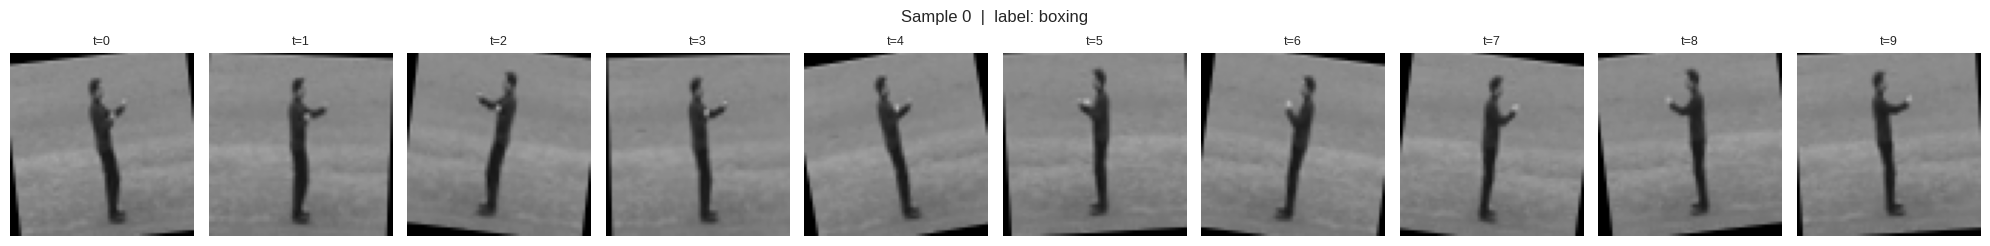

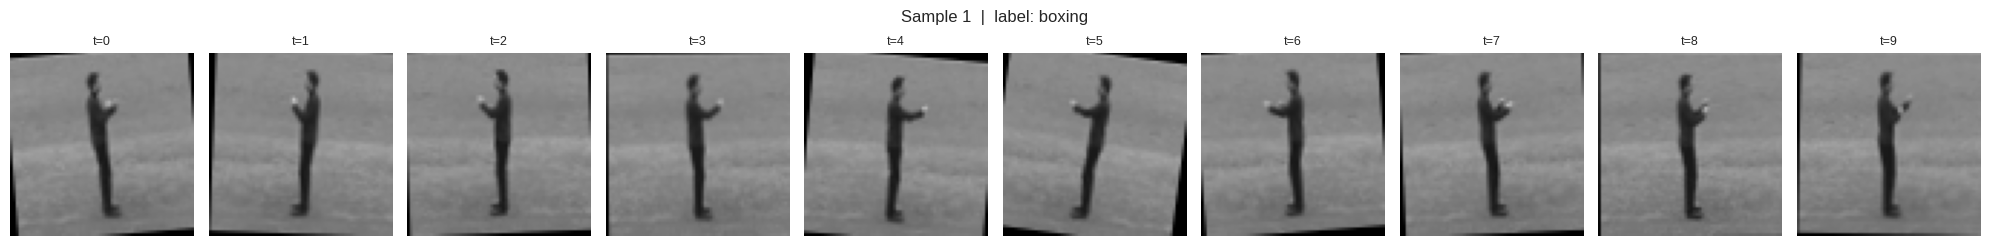

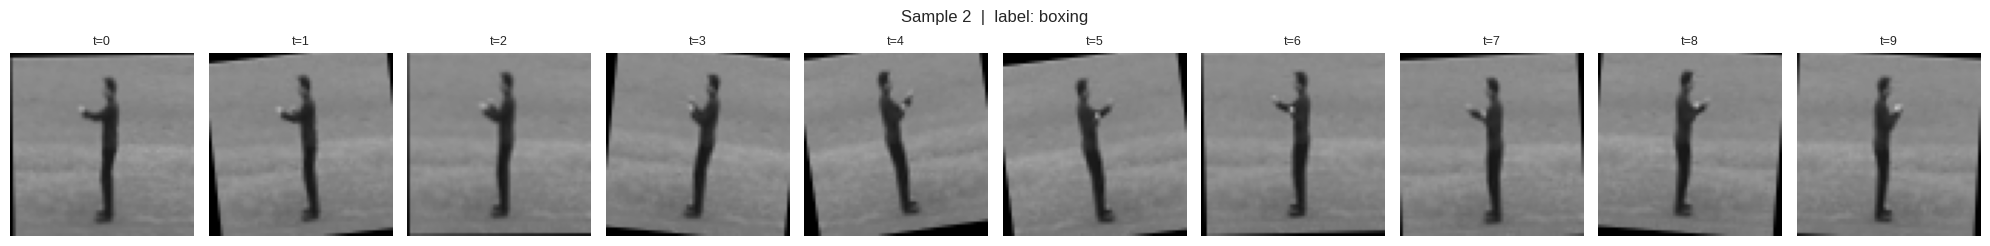

In [5]:
def visualize_sequence(frames, label, title=""):
    """ Visualizing a sequence of grayscale frames with their action label. """
    T = frames.shape[0]
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(1, T, figsize=(2 * T, 2.5))
    fig.suptitle(f"{title}  |  label: {KTHDataset.CLASSES[label]}", fontsize=12)
    for t, ax in enumerate(axes):
        ax.imshow(frames[t, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"t={t}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


for i in range(3):
    frames, label = train_dataset[i]
    visualize_sequence(frames, label, title=f"Sample {i}")

## DataLoaders

In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

frames, labels = next(iter(train_loader))
print(f"Batch frames shape: {frames.shape}")   # (B, T, 1, 64, 64)
print(f"Batch labels shape: {labels.shape}")

/home/user/dagkusue1/visionlab/lib/python3.12/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Batch frames shape: torch.Size([32, 10, 1, 64, 64])
Batch labels shape: torch.Size([32])


# Task 1: Custom LSTM from Scratch

Implement the LSTM equations manually without using `nn.LSTM` or `nn.LSTMCell`.

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$g_t = \tanh(W_g [h_{t-1}, x_t] + b_g)$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot g_t$$
$$h_t = o_t \odot \tanh(c_t)$$

In [7]:
class MyLSTMCell(nn.Module):
    """
    LSTM cell implemented from scratch.
    All 4 gate projections are fused into a single Linear layer for efficiency.
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size)

    def forward(self, x, h_prev, c_prev):
        gates = self.W(torch.cat([x, h_prev], dim=1))
        f, i, g, o = gates.chunk(4, dim=1)
        f = torch.sigmoid(f)
        i = torch.sigmoid(i)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c


class MyLSTM(nn.Module):
    """ Stacked LSTM built from MyLSTMCells. """
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        cells = [MyLSTMCell(input_size if l == 0 else hidden_size, hidden_size)
                 for l in range(num_layers)]
        self.cells = nn.ModuleList(cells)

    def forward(self, x):
        B, T, _ = x.shape
        h = [torch.zeros(B, self.hidden_size, device=x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(B, self.hidden_size, device=x.device) for _ in range(self.num_layers)]
        outputs = []
        for t in range(T):
            inp = x[:, t, :]
            for l in range(self.num_layers):
                h[l], c[l] = self.cells[l](inp, h[l], c[l])
                inp = h[l]
            outputs.append(h[-1])
        return torch.stack(outputs, dim=1), (h, c)   # (B, T, hidden_size)


# Sanity check
_x = torch.randn(4, NUM_FRAMES, 128)
_out, _ = MyLSTM(input_size=128, hidden_size=64, num_layers=2)(_x)
print(f"MyLSTM output shape: {_out.shape}")   # (4, 10, 64)

MyLSTM output shape: torch.Size([4, 10, 64])


# Task 1: Custom ConvLSTM from Scratch

ConvLSTM replaces all matrix multiplications in LSTM with **2D convolutions**, preserving spatial structure.

$$f_t = \sigma(W_f * [H_{t-1}, X_t] + b_f)$$
$$i_t = \sigma(W_i * [H_{t-1}, X_t] + b_i)$$
$$g_t = \tanh(W_g * [H_{t-1}, X_t] + b_g)$$
$$o_t = \sigma(W_o * [H_{t-1}, X_t] + b_o)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot g_t$$
$$H_t = o_t \odot \tanh(C_t)$$

where $*$ denotes convolution and $H_t, C_t$ are spatial maps `(B, C, H, W)`.

In [8]:
class ConvLSTMCell(nn.Module):
    """
    ConvLSTM cell implemented from scratch.
    Replaces all linear projections in LSTM with 2D convolutions to preserve spatial structure.
    """
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            input_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
        )

    def forward(self, x, h_prev, c_prev):
        gates = self.conv(torch.cat([x, h_prev], dim=1))
        f, i, g, o = gates.chunk(4, dim=1)
        f = torch.sigmoid(f)
        i = torch.sigmoid(i)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c


class ConvLSTM(nn.Module):
    """ Stacked ConvLSTM built from ConvLSTMCells. """
    def __init__(self, input_channels, hidden_channels, num_layers=1, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.num_layers      = num_layers
        cells = [ConvLSTMCell(input_channels if l == 0 else hidden_channels, hidden_channels, kernel_size)
                 for l in range(num_layers)]
        self.cells = nn.ModuleList(cells)

    def forward(self, x):
        B, T, _, H, W = x.shape
        h = [torch.zeros(B, self.hidden_channels, H, W, device=x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(B, self.hidden_channels, H, W, device=x.device) for _ in range(self.num_layers)]
        outputs = []
        for t in range(T):
            inp = x[:, t]
            for l in range(self.num_layers):
                h[l], c[l] = self.cells[l](inp, h[l], c[l])
                inp = h[l]
            outputs.append(h[-1])
        return torch.stack(outputs, dim=1), (h, c)   # (B, T, hidden_channels, H, W)


# Sanity check
_x = torch.randn(2, NUM_FRAMES, 64, 8, 8)
_out, _ = ConvLSTM(input_channels=64, hidden_channels=32, num_layers=2)(_x)
print(f"ConvLSTM output shape: {_out.shape}")   # (2, 10, 32, 8, 8)

ConvLSTM output shape: torch.Size([2, 10, 32, 8, 8])


# Task 2: Model Architectures

## Vector RNN Classifier
Used for: **nn.LSTMCell**, **nn.GRUCell**, **MyLSTM**

Pipeline: `frames → CNN encoder → embeddings → RNN → Linear classifier`

In [9]:
class VectorRNNClassifier(nn.Module):
    """
    Action classifier: CNN encoder → vector-based RNN → Linear classifier.
    The encoder compresses each frame to a fixed-size embedding independently,
    then the RNN processes the sequence of embeddings over time.
    Supports rnn_type in {'lstm_cell', 'gru_cell', 'my_lstm'}.
    """
    def __init__(self, emb_dim=128, hidden_dim=256, num_layers=2, num_classes=6, rnn_type="lstm_cell"):
        super().__init__()
        assert rnn_type in ("lstm_cell", "gru_cell", "my_lstm")
        self.rnn_type   = rnn_type
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),    # 64->32
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),   # 32->16
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 16->8
            nn.Conv2d(128, emb_dim, 3, 1, 1),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        if rnn_type == "lstm_cell":
            self.rnns = nn.ModuleList([
                nn.LSTMCell(emb_dim if i == 0 else hidden_dim, hidden_dim)
                for i in range(num_layers)
            ])
        elif rnn_type == "gru_cell":
            self.rnns = nn.ModuleList([
                nn.GRUCell(emb_dim if i == 0 else hidden_dim, hidden_dim)
                for i in range(num_layers)
            ])
        elif rnn_type == "my_lstm":
            self.rnns = MyLSTM(emb_dim, hidden_dim, num_layers)

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape

        # encode all frames in parallel
        emb = self.encoder(x.view(B * T, C, H, W))  # (B*T, emb_dim, 1, 1)
        emb = emb.view(B, T, -1)                     # (B, T, emb_dim)

        if self.rnn_type == "my_lstm":
            out, _ = self.rnns(emb)
            last_h = out[:, -1, :]
        else:
            h = [torch.zeros(B, self.hidden_dim, device=x.device) for _ in range(self.num_layers)]
            c = [torch.zeros(B, self.hidden_dim, device=x.device) for _ in range(self.num_layers)]
            for t in range(T):
                inp = emb[:, t, :]
                for idx, rnn in enumerate(self.rnns):
                    if self.rnn_type == "lstm_cell":
                        h[idx], c[idx] = rnn(inp, (h[idx], c[idx]))
                    else:  # gru_cell
                        h[idx] = rnn(inp, h[idx])
                    inp = h[idx]
            last_h = h[-1]

        return self.classifier(last_h)

## ConvLSTM Classifier

Pipeline: `frames → lightweight CNN encoder → spatial maps → ConvLSTM → Conv + AvgPool → Linear`

In [10]:
class ConvLSTMClassifier(nn.Module):
    """
    Action classifier: CNN encoder → ConvLSTM → Conv + AvgPool → Linear.
    Unlike VectorRNNClassifier, the encoder does not flatten spatial dimensions,
    allowing ConvLSTM to reason over space and time simultaneously.
    """
    def __init__(self, enc_channels=64, hidden_channels=64, num_layers=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, enc_channels, 3, 1, 1), nn.BatchNorm2d(enc_channels), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(enc_channels, enc_channels, 3, 1, 1), nn.BatchNorm2d(enc_channels), nn.ReLU(), nn.MaxPool2d(2),
        )   # 64x64 → 8x8

        self.conv_lstm = ConvLSTM(enc_channels, hidden_channels, num_layers)

        self.classifier = nn.Sequential(
            nn.Conv2d(hidden_channels, 128, 3, 1, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        # encode each frame independently
        enc = self.encoder(x.view(B * T, C, H, W))
        _, ch, h, w = enc.shape
        enc = enc.view(B, T, ch, h, w)

        # ConvLSTM over time, classify using final hidden state
        out, _ = self.conv_lstm(enc)
        return self.classifier(out[:, -1])

## Helper Functions

In [11]:
def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params


def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]
    return smooth_f


for name, rnn_type in [("LSTMCell", "lstm_cell"), ("GRUCell", "gru_cell"), ("MyLSTM", "my_lstm")]:
    m = VectorRNNClassifier(rnn_type=rnn_type)
    print(f"VectorRNNClassifier ({name}): {count_model_params(m):,} params")

m = ConvLSTMClassifier()
print(f"ConvLSTMClassifier:              {count_model_params(m):,} params")

VectorRNNClassifier (LSTMCell): 1,163,846 params
VectorRNNClassifier (GRUCell): 933,446 params
VectorRNNClassifier (MyLSTM): 1,161,798 params
ConvLSTMClassifier:              721,030 params


## Training

In [12]:
def train_epoch(model, train_loader, optimizer, criterion, epoch, device):
    """ Training the model for one epoch """
    loss_list = []
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader))
    for i, (frames, labels) in progress_bar:
        frames, labels = frames.to(device), labels.to(device)

        # forward pass
        outputs = model(frames)

        # computing error
        loss = criterion(outputs, labels)
        loss_list.append(loss.item())

        # removing accumulated gradients
        optimizer.zero_grad()

        # backpropagating error to compute gradients
        loss.backward()

        # updating parameters
        optimizer.step()

        progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

    return np.mean(loss_list), loss_list


@torch.no_grad()
def eval_model(model, eval_loader, criterion, device):
    """ Evaluating the model for either validation or test """
    model.eval()
    correct = 0
    total   = 0
    loss_list = []

    for frames, labels in eval_loader:
        frames, labels = frames.to(device), labels.to(device)
        outputs = model(frames)
        loss_list.append(criterion(outputs, labels).item())
        preds = torch.argmax(outputs, dim=1)
        correct += len(torch.where(preds == labels)[0])
        total   += len(labels)

    accuracy = correct / total * 100
    loss     = np.mean(loss_list)
    return accuracy, loss


def train_model(model, optimizer, scheduler, criterion, train_loader, valid_loader, num_epochs, writer=None, name=""):
    """ Training a model for a given number of epochs """
    train_loss  = []
    val_loss    = []
    loss_iters  = []
    valid_acc   = []

    best_valid_acc   = 0.0
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        mean_loss, cur_loss_iters = train_epoch(
            model, train_loader, optimizer, criterion, epoch, device
        )
        scheduler.step()

        model.eval()
        accuracy, loss = eval_model(model, valid_loader, criterion, device)

        train_loss.append(mean_loss)
        val_loss.append(loss)
        loss_iters += cur_loss_iters
        valid_acc.append(accuracy)

        if accuracy > best_valid_acc:
            best_valid_acc   = accuracy
            best_model_state = copy.deepcopy(model.state_dict())

        if writer is not None:
            writer.add_scalar(f"{name}/Loss/train",      mean_loss, epoch + 1)
            writer.add_scalar(f"{name}/Loss/valid",      loss,      epoch + 1)
            writer.add_scalar(f"{name}/Accuracy/valid",  accuracy,  epoch + 1)

        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"    Train loss: {round(mean_loss, 5)}")
        print(f"    Valid loss: {round(loss, 5)}")
        print(f"    Accuracy: {round(accuracy, 2)}%")
        print()

    model.load_state_dict(best_model_state)
    print("Training completed")
    return {
        "train_loss": train_loss,
        "val_loss":   val_loss,
        "loss_iters": loss_iters,
        "valid_acc":  valid_acc,
    }


def plot_training_progress(loss_iters, title="Training Progress"):
    """ Plotting per-iteration training loss on linear and log scale """
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(18, 5)

    smooth_loss = smooth(loss_iters, 31)
    for a, scale in zip(ax, ["linear", "log"]):
        a.plot(loss_iters,  c="blue", label="Loss",         linewidth=3, alpha=0.5)
        a.plot(smooth_loss, c="red",  label="Smoothed Loss", linewidth=3)
        a.legend(loc="best")
        a.set_xlabel("Iteration")
        a.set_ylabel("CE Loss")
        a.set_title(f"{title} ({scale} scale)")
        if scale == "log":
            a.set_yscale("log")
    plt.show()


def plot_loss_curves(stats, title=""):
    """ Plotting train/val loss and validation accuracy curves per epoch """
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(18, 5)

    epochs = np.arange(1, len(stats["train_loss"]) + 1)
    ax[0].plot(epochs, stats["train_loss"], c="red",  label="Train Loss", linewidth=3)
    ax[0].plot(epochs, stats["val_loss"],   c="blue", label="Valid Loss", linewidth=3)
    ax[0].legend(loc="best")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("CE Loss")
    ax[0].set_title(f"Loss Curves  {title}")

    best_acc = max(stats["valid_acc"])
    best_ep  = stats["valid_acc"].index(best_acc) + 1
    ax[1].plot(epochs, stats["valid_acc"], c="red", linewidth=3)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy (%)")
    ax[1].set_title(f"Validation Accuracy  (max={round(best_acc, 2)}% @ epoch {best_ep})  {title}")
    plt.show()

## Experiment Runner

In [13]:
def run_experiment(model, name, num_epochs=NUM_EPOCHS, lr=LR):
    """ Training and evaluating a model, logging to TensorBoard """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.2)
    writer    = SummaryWriter(log_dir=f"tboard_logs/{name}")

    print(f"\nTraining {name}")
    print(f"Learnable parameters: {count_model_params(model):,}")

    stats = train_model(
        model=model, optimizer=optimizer, scheduler=scheduler,
        criterion=criterion, train_loader=train_loader, valid_loader=valid_loader,
        num_epochs=num_epochs, writer=writer, name=name,
    )

    test_acc, test_loss = eval_model(model, test_loader, criterion, device)
    writer.close()

    print(f"Test accuracy: {round(test_acc, 2)}%")
    return {
        "name":      name,
        "model":     model,
        "stats":     stats,
        "test_acc":  test_acc,
        "test_loss": test_loss,
        "n_params":  count_model_params(model),
    }

# Task 2: Train & Compare All RNN Models


Training LSTMCell
Learnable parameters: 4,069,574


Epoch 1 Iter 1135: loss 1.53741. : 100%|██████████| 1135/1135 [00:27<00:00, 41.28it/s]


Epoch 1/15
    Train loss: 1.32334
    Valid loss: 1.17503
    Accuracy: 42.95%



Epoch 2 Iter 1135: loss 1.01214. : 100%|██████████| 1135/1135 [00:26<00:00, 42.88it/s]


Epoch 2/15
    Train loss: 1.0788
    Valid loss: 0.96905
    Accuracy: 52.25%



...

Epoch 13/15
    Train loss: 0.48233
    Valid loss: 0.7931
    Accuracy: 69.53%



Epoch 14 Iter 1135: loss 0.54971. : 100%|██████████| 1135/1135 [00:26<00:00, 42.57it/s]


Epoch 14/15
    Train loss: 0.47781
    Valid loss: 0.78509
    Accuracy: 69.66%



Epoch 15 Iter 1135: loss 0.31754. : 100%|██████████| 1135/1135 [00:26<00:00, 42.24it/s]


Epoch 15/15
    Train loss: 0.46974
    Valid loss: 0.75318
    Accuracy: 70.82%

Training completed
Test accuracy: 63.0%


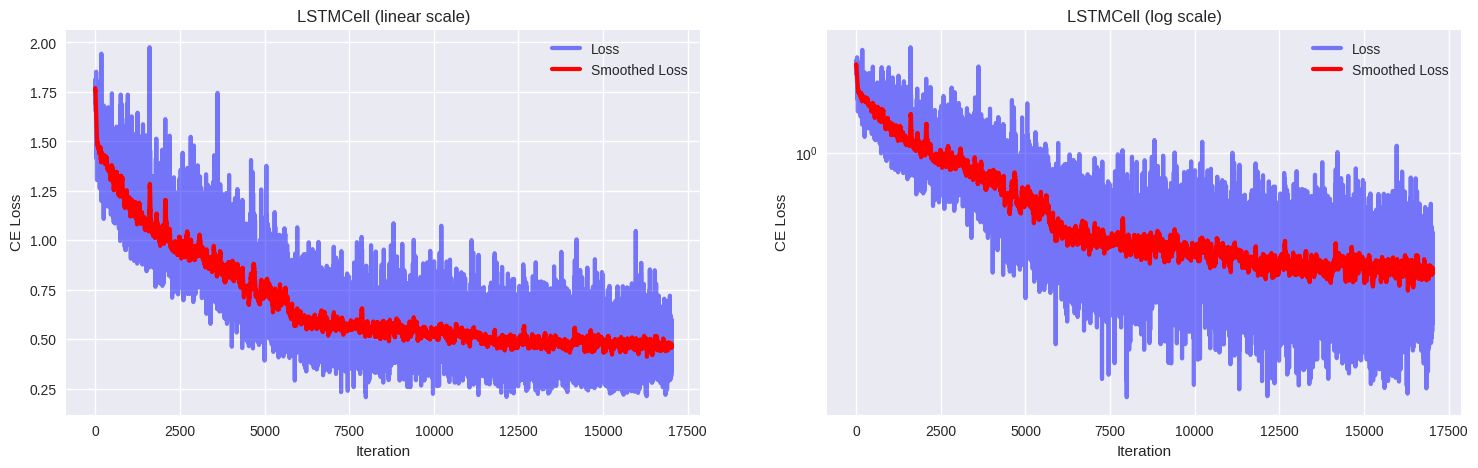

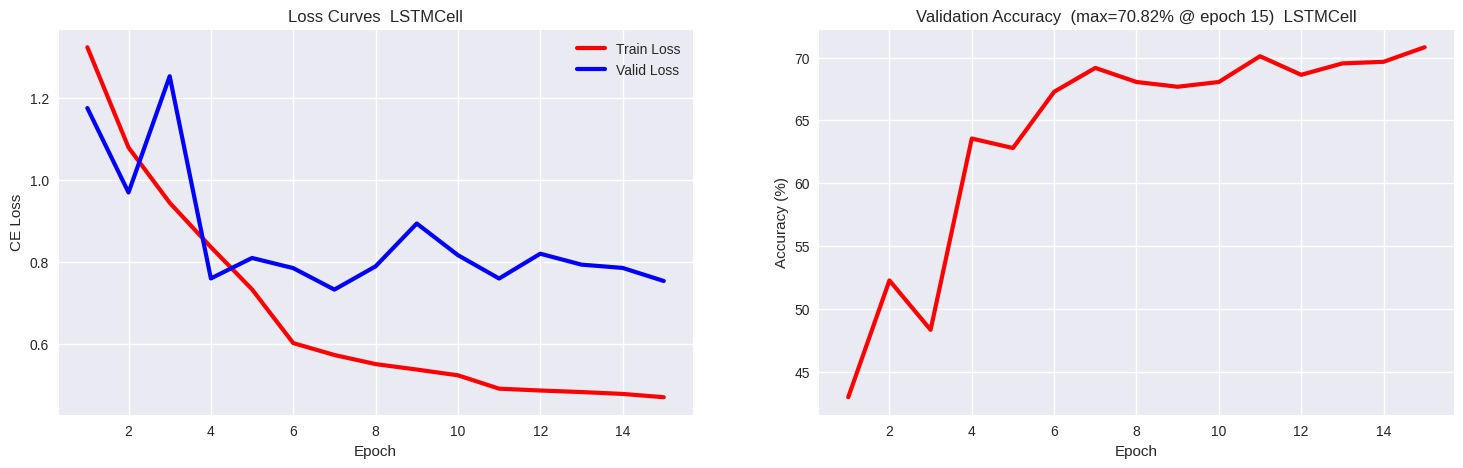

In [14]:
results = {}

results["LSTMCell"] = run_experiment(
    VectorRNNClassifier(emb_dim=256, hidden_dim=512, num_layers=2, rnn_type="lstm_cell"),
    name="LSTMCell",
)

plot_training_progress(results["LSTMCell"]["stats"]["loss_iters"], title="LSTMCell")
plot_loss_curves(results["LSTMCell"]["stats"], title="LSTMCell")


Training GRUCell
Learnable parameters: 3,150,022


Epoch 1 Iter 1135: loss 1.25715. : 100%|██████████| 1135/1135 [00:26<00:00, 42.74it/s]


Epoch 1/15
    Train loss: 1.30803
    Valid loss: 1.07512
    Accuracy: 51.98%



Epoch 2 Iter 1135: loss 0.96015. : 100%|██████████| 1135/1135 [00:26<00:00, 42.21it/s]


Epoch 2/15
    Train loss: 0.95722
    Valid loss: 1.33978
    Accuracy: 51.47%



...

Epoch 13/15
    Train loss: 0.43293
    Valid loss: 0.55747
    Accuracy: 75.89%



Epoch 14 Iter 1135: loss 0.57431. : 100%|██████████| 1135/1135 [00:26<00:00, 42.47it/s]


Epoch 14/15
    Train loss: 0.43124
    Valid loss: 0.56098
    Accuracy: 75.62%



Epoch 15 Iter 1135: loss 0.27561. : 100%|██████████| 1135/1135 [00:26<00:00, 42.17it/s]


Epoch 15/15
    Train loss: 0.42673
    Valid loss: 0.56803
    Accuracy: 75.7%

Training completed
Test accuracy: 65.78%


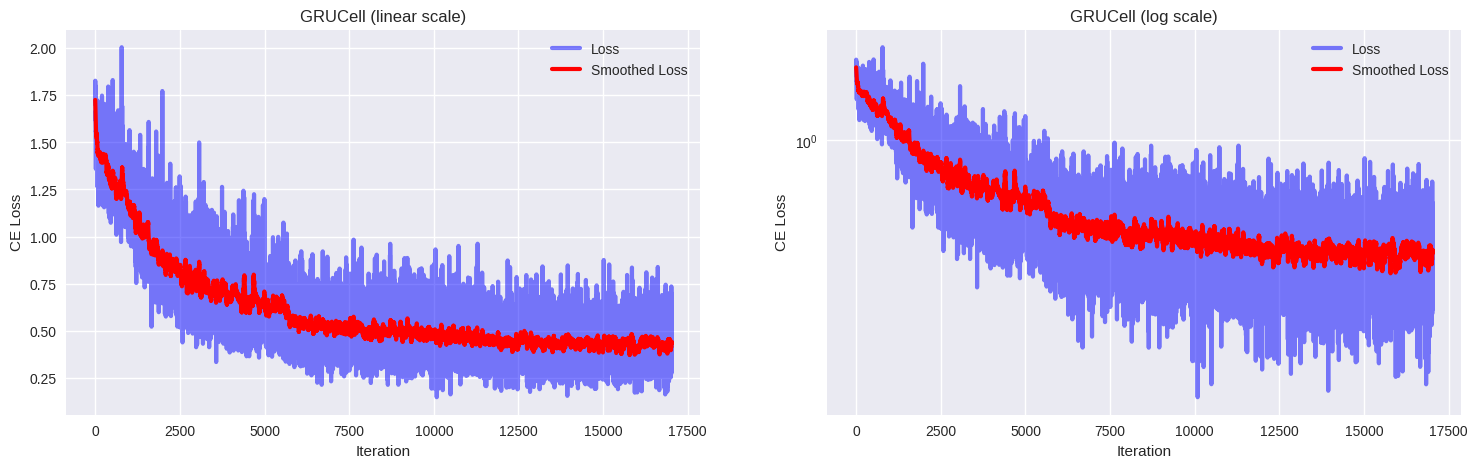

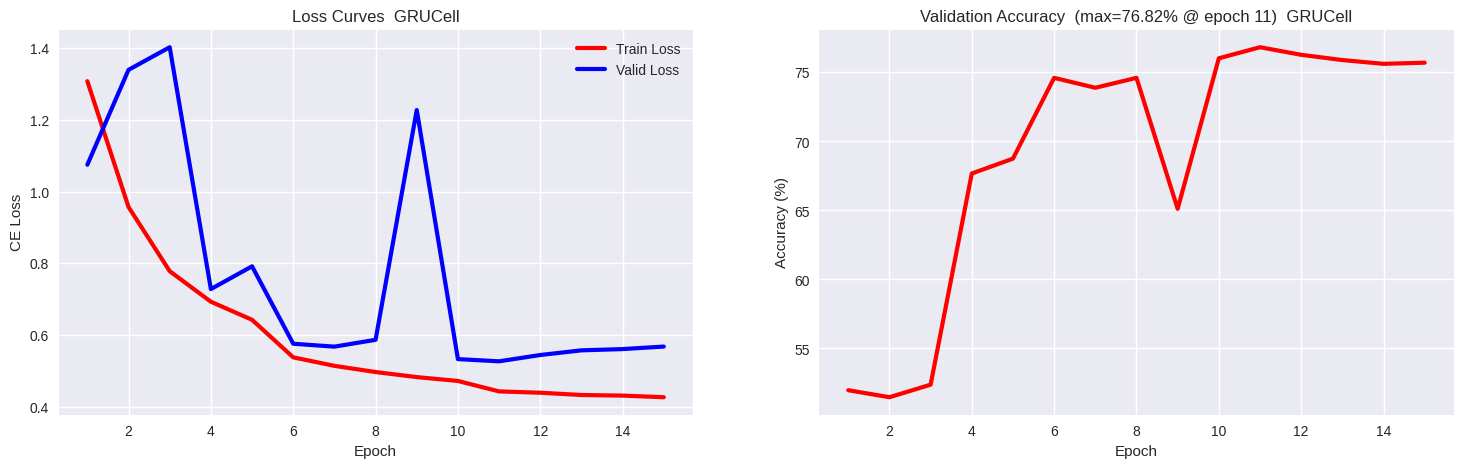

In [15]:
results["GRUCell"] = run_experiment(
    VectorRNNClassifier(emb_dim=256, hidden_dim=512, num_layers=2, rnn_type="gru_cell"),
    name="GRUCell",
)

plot_training_progress(results["GRUCell"]["stats"]["loss_iters"], title="GRUCell")
plot_loss_curves(results["GRUCell"]["stats"], title="GRUCell")


Training MyLSTM
Learnable parameters: 4,065,478


Epoch 1 Iter 1135: loss 0.98154. : 100%|██████████| 1135/1135 [00:28<00:00, 39.45it/s]


Epoch 1/15
    Train loss: 1.32017
    Valid loss: 1.28308
    Accuracy: 38.41%



Epoch 2 Iter 1135: loss 1.09322. : 100%|██████████| 1135/1135 [00:29<00:00, 37.91it/s]


Epoch 2/15
    Train loss: 1.07369
    Valid loss: 1.02537
    Accuracy: 51.07%



...

Epoch 13/15
    Train loss: 0.47603
    Valid loss: 1.07814
    Accuracy: 63.3%



Epoch 14 Iter 1135: loss 0.58988. : 100%|██████████| 1135/1135 [00:29<00:00, 38.31it/s]


Epoch 14/15
    Train loss: 0.47179
    Valid loss: 1.00129
    Accuracy: 66.05%



Epoch 15 Iter 1135: loss 0.70849. : 100%|██████████| 1135/1135 [00:29<00:00, 38.79it/s]


Epoch 15/15
    Train loss: 0.46941
    Valid loss: 1.03811
    Accuracy: 64.97%

Training completed
Test accuracy: 61.39%


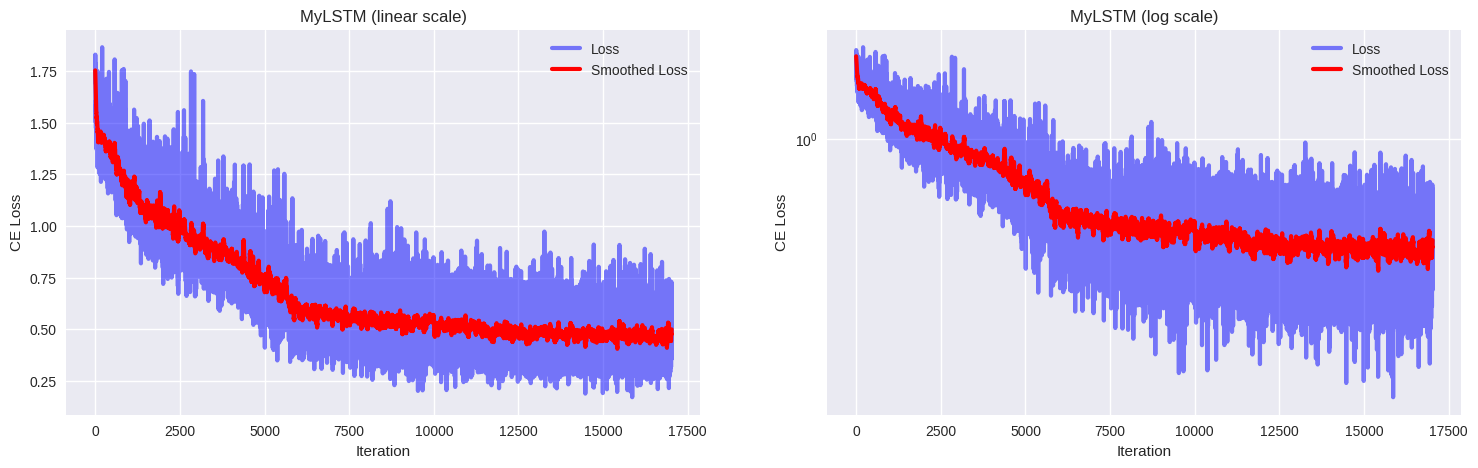

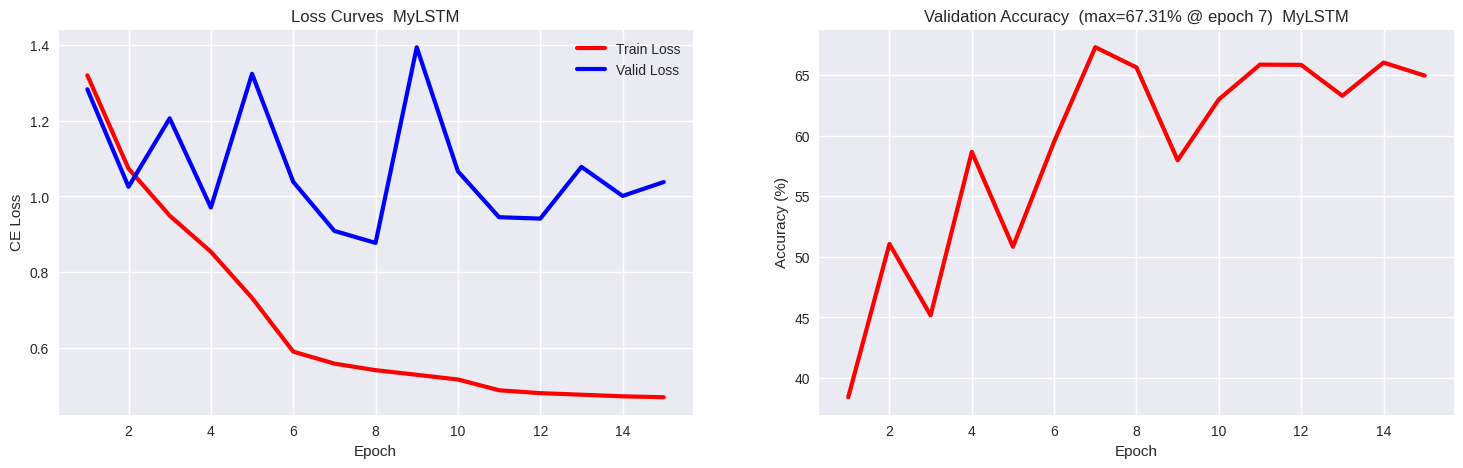

In [16]:
results["MyLSTM"] = run_experiment(
    VectorRNNClassifier(emb_dim=256, hidden_dim=512, num_layers=2, rnn_type="my_lstm"),
    name="MyLSTM",
)

plot_training_progress(results["MyLSTM"]["stats"]["loss_iters"], title="MyLSTM")
plot_loss_curves(results["MyLSTM"]["stats"], title="MyLSTM")


Training ConvLSTM
Learnable parameters: 2,694,150


Epoch 1 Iter 1135: loss 0.54201. : 100%|██████████| 1135/1135 [00:49<00:00, 22.75it/s]


Epoch 1/15
    Train loss: 1.02282
    Valid loss: 0.85187
    Accuracy: 59.05%



Epoch 2 Iter 1135: loss 0.56543. : 100%|██████████| 1135/1135 [00:50<00:00, 22.66it/s]


Epoch 2/15
    Train loss: 0.6254
    Valid loss: 0.54861
    Accuracy: 74.65%



...

Epoch 13/15
    Train loss: 0.28952
    Valid loss: 0.75801
    Accuracy: 72.36%



Epoch 14 Iter 1135: loss 0.21641. : 100%|██████████| 1135/1135 [00:49<00:00, 23.14it/s]


Epoch 14/15
    Train loss: 0.28492
    Valid loss: 0.81808
    Accuracy: 71.43%



Epoch 15 Iter 1135: loss 0.15836. : 100%|██████████| 1135/1135 [00:49<00:00, 23.15it/s]


Epoch 15/15
    Train loss: 0.28052
    Valid loss: 0.80821
    Accuracy: 72.41%

Training completed
Test accuracy: 70.44%


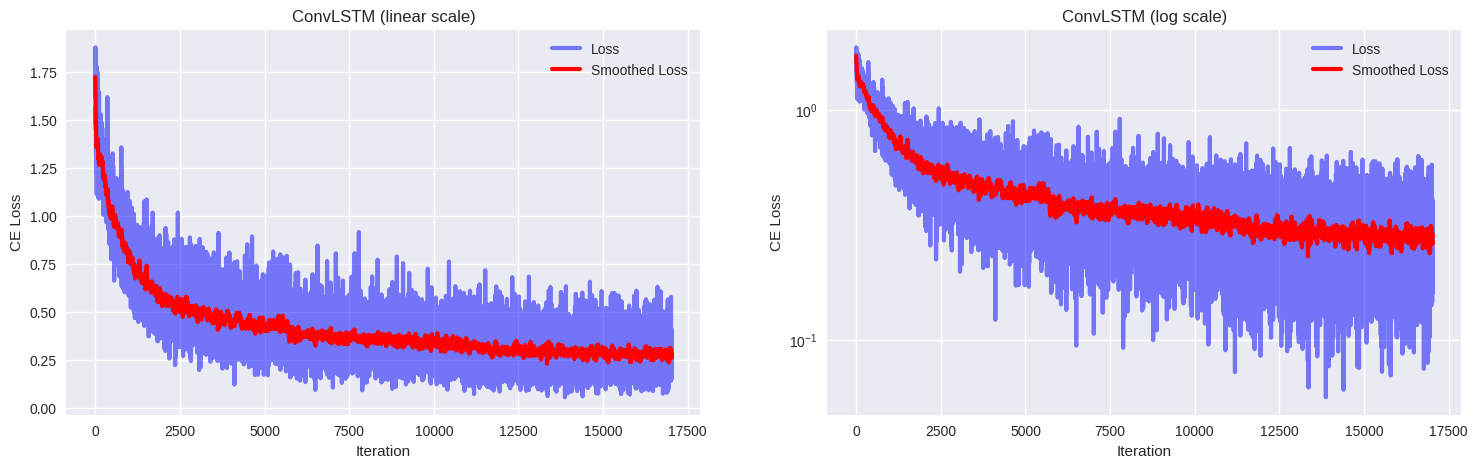

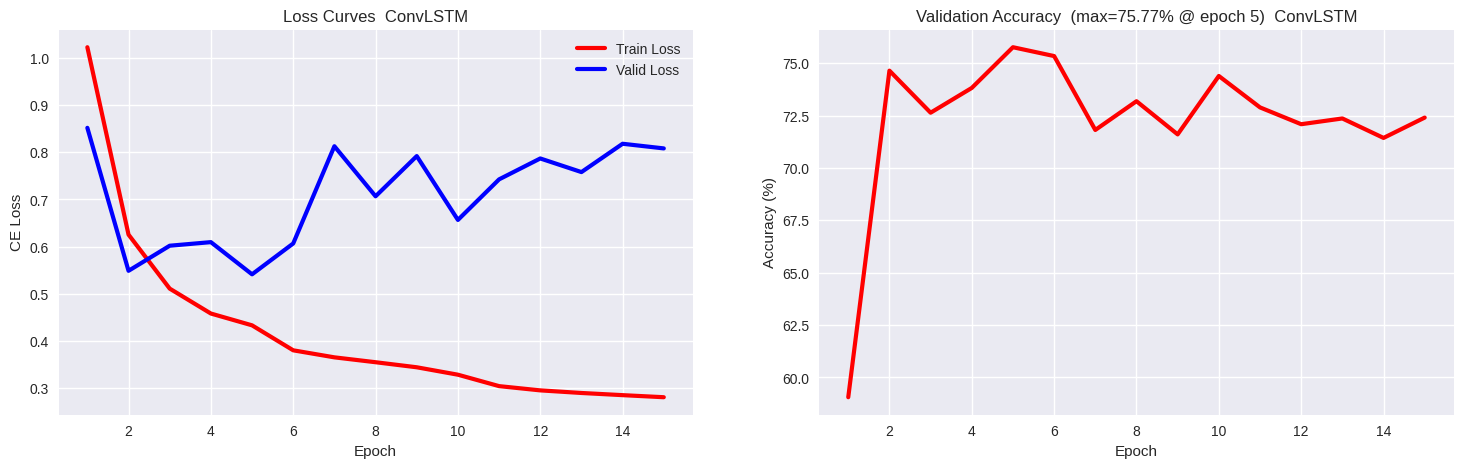

In [17]:
results["ConvLSTM"] = run_experiment(
    ConvLSTMClassifier(enc_channels=128, hidden_channels=128, num_layers=2),
    name="ConvLSTM",
)

plot_training_progress(results["ConvLSTM"]["stats"]["loss_iters"], title="ConvLSTM")
plot_loss_curves(results["ConvLSTM"]["stats"], title="ConvLSTM")

## Results Summary

In [18]:
print(f"{'Model':<12} {'Params':>10} {'Best Val Acc':>14} {'Test Acc':>10} {'Test Loss':>10}")
print("-" * 60)

for name, r in results.items():
    best_val = max(r["stats"]["valid_acc"])
    print(f"{name:<12} {r['n_params']:>10,} {best_val:>13.2f}% {r['test_acc']:>9.2f}% {r['test_loss']:>10.4f}")

Model            Params   Best Val Acc   Test Acc  Test Loss
------------------------------------------------------------
LSTMCell      4,069,574         70.82%     63.00%     1.1408
GRUCell       3,150,022         76.82%     65.78%     0.9665
MyLSTM        4,065,478         67.31%     61.39%     1.2476
ConvLSTM      2,694,150         75.77%     70.44%     0.8710


## Loss & Accuracy Curves

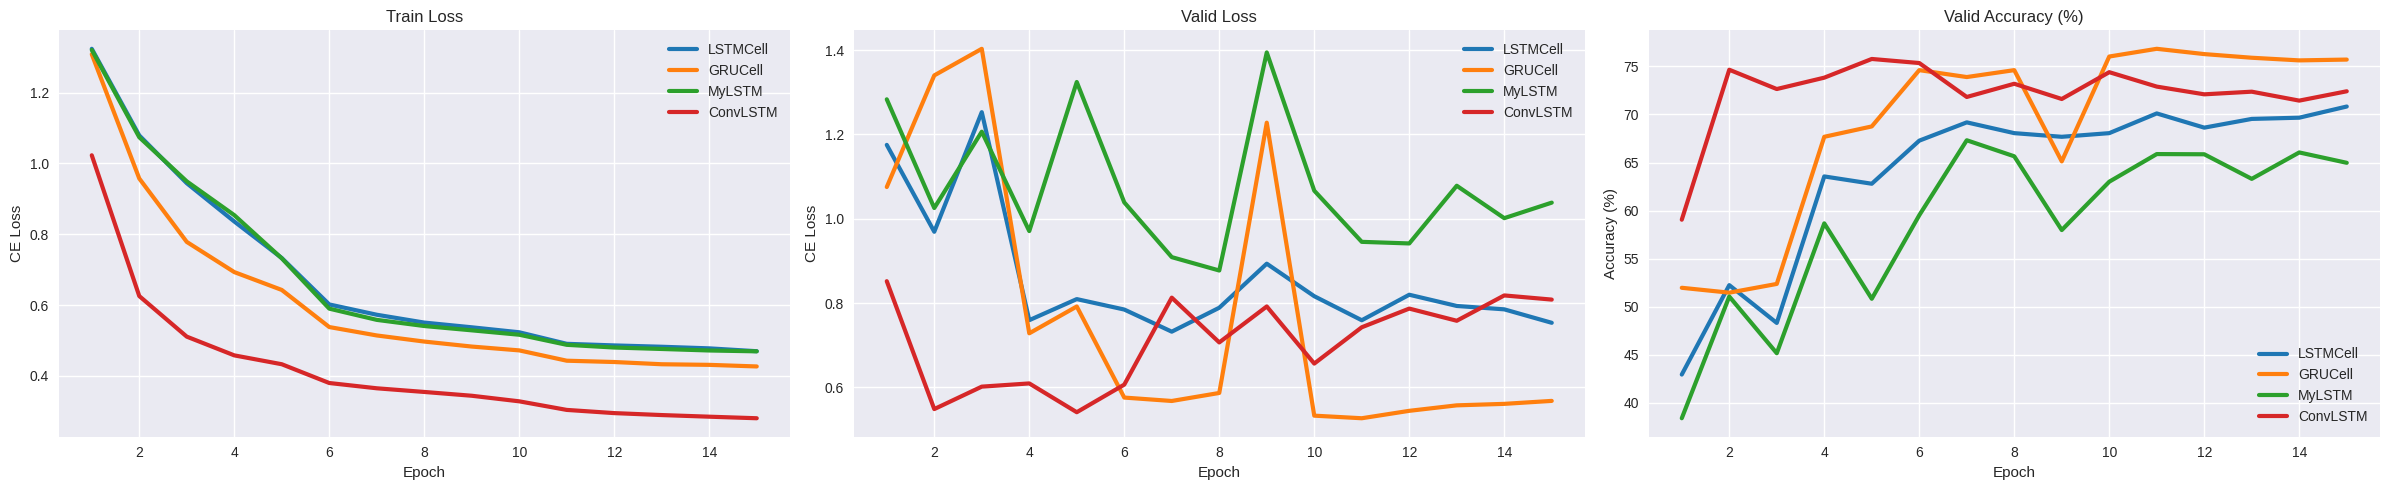

In [19]:
plt.style.use('seaborn-v0_8')
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(24, 5)

for (name, r), color in zip(results.items(), colors):
    epochs = np.arange(1, len(r["stats"]["train_loss"]) + 1)
    ax[0].plot(epochs, r["stats"]["train_loss"], label=name, color=color, linewidth=3)
    ax[1].plot(epochs, r["stats"]["val_loss"],   label=name, color=color, linewidth=3)
    ax[2].plot(epochs, r["stats"]["valid_acc"],  label=name, color=color, linewidth=3)

for a, title, ylabel in zip(ax,
    ["Train Loss", "Valid Loss", "Valid Accuracy (%)"],
    ["CE Loss",    "CE Loss",    "Accuracy (%)"]):
    a.legend(loc="best")
    a.set_xlabel("Epoch")
    a.set_ylabel(ylabel)
    a.set_title(title)

plt.tight_layout()
plt.show()

# Model Analysis

In [20]:
def plot_confusion_matrix(model, test_loader, device, model_name=""):
    """ Plotting the confusion matrix on the test set """
    all_preds  = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for frames, labels in test_loader:
            frames, labels = frames.to(device), labels.to(device)
            preds = torch.argmax(model(frames), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    classes = KTHDataset.CLASSES
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for t, p in zip(all_labels, all_preds):
        cm[t][p] += 1

    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {model_name}")
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(cm[i][j]), ha="center", va="center",
                    color="white" if cm[i][j] > cm.max() / 2 else "black", fontsize=9)
    plt.tight_layout()
    plt.show()


def visualize_predictions(model, test_dataset, device, n=12, model_name=""):
    """ Visualizing model predictions on random test samples """
    indices = np.random.randint(0, len(test_dataset), size=n)
    classes = KTHDataset.CLASSES

    model.eval()
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * n // 2, 6))
    axes = axes.flatten()

    with torch.no_grad():
        for plot_i, idx in enumerate(indices):
            frames, label = test_dataset[idx]
            pred = model(frames.unsqueeze(0).to(device))
            pred_label = torch.argmax(pred, dim=1).item()

            # show middle frame of the subsequence
            mid_frame = frames[NUM_FRAMES // 2, 0].numpy()
            axes[plot_i].imshow(mid_frame, cmap="gray", vmin=0, vmax=1)
            axes[plot_i].axis("off")
            color = "green" if pred_label == label else "red"
            axes[plot_i].set_title(
                f"T: {classes[label]}\nP: {classes[pred_label]}",
                color=color, fontsize=8
            )

    plt.suptitle(f"{model_name}  —  Green = correct, Red = wrong", fontsize=11)
    plt.tight_layout()
    plt.show()


 LSTMCell


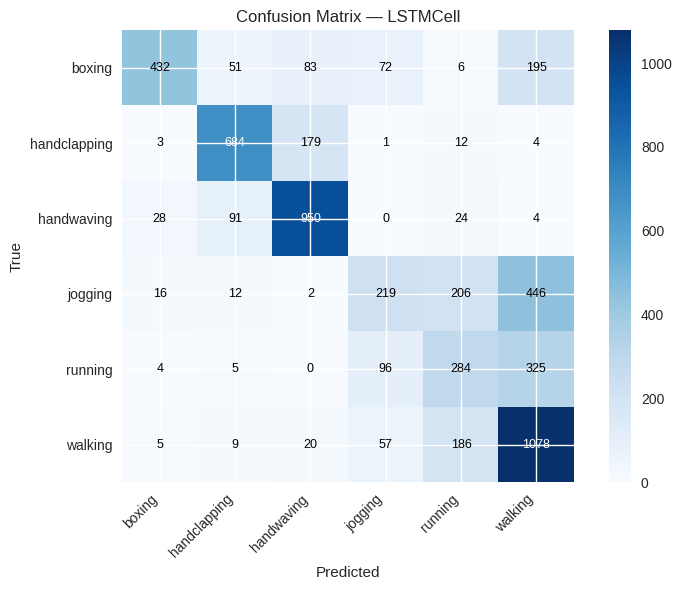

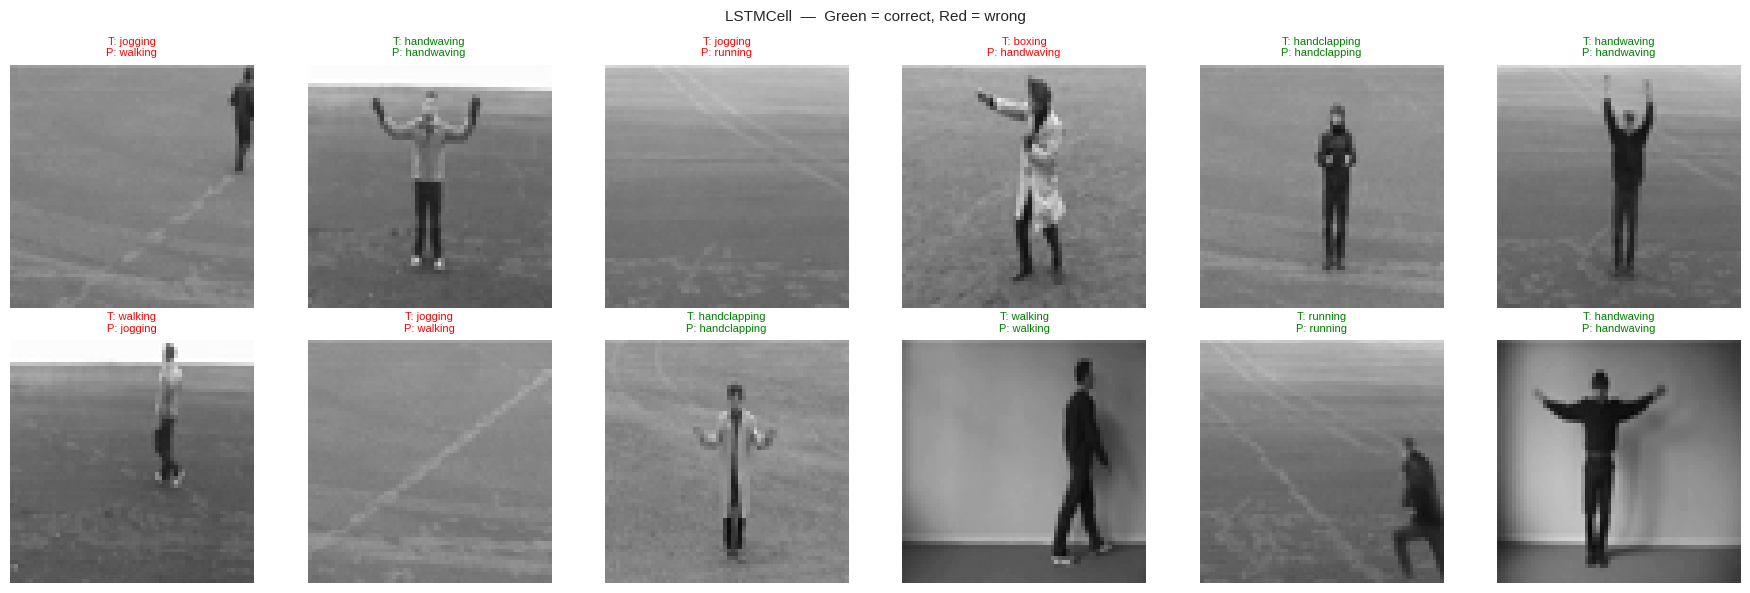


 GRUCell


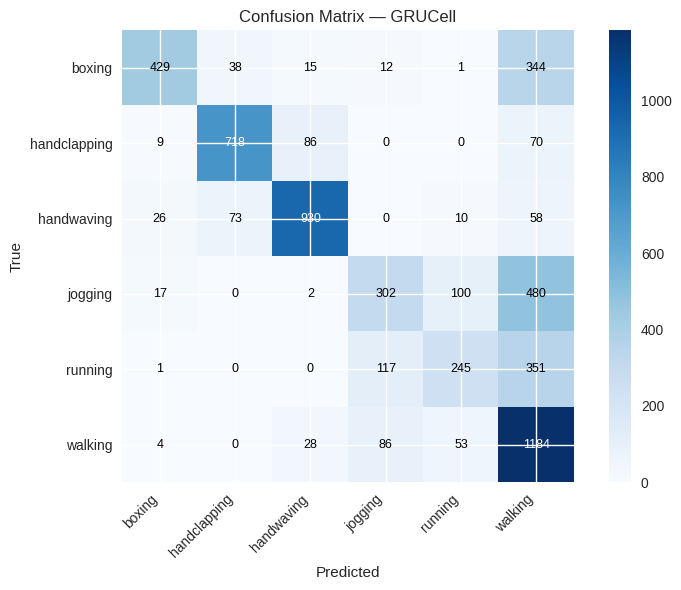

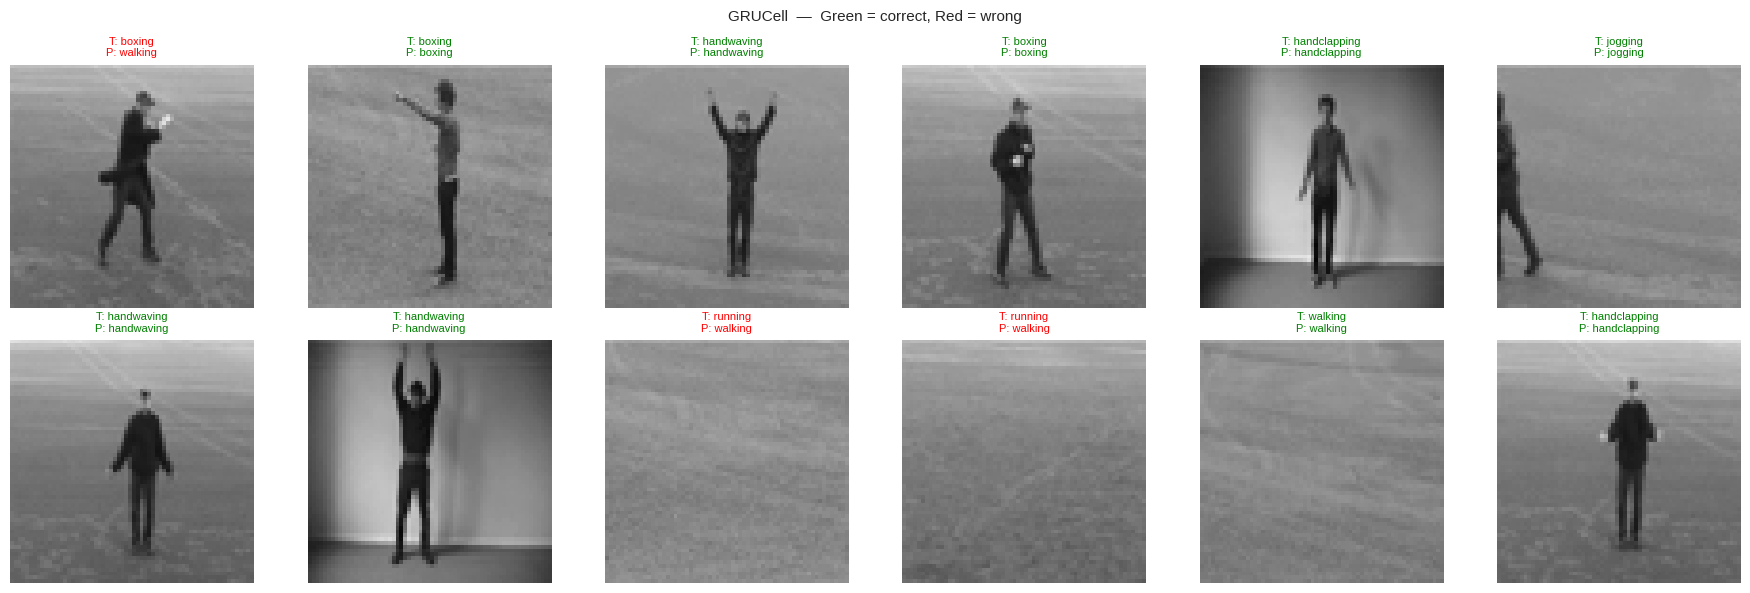


 MyLSTM


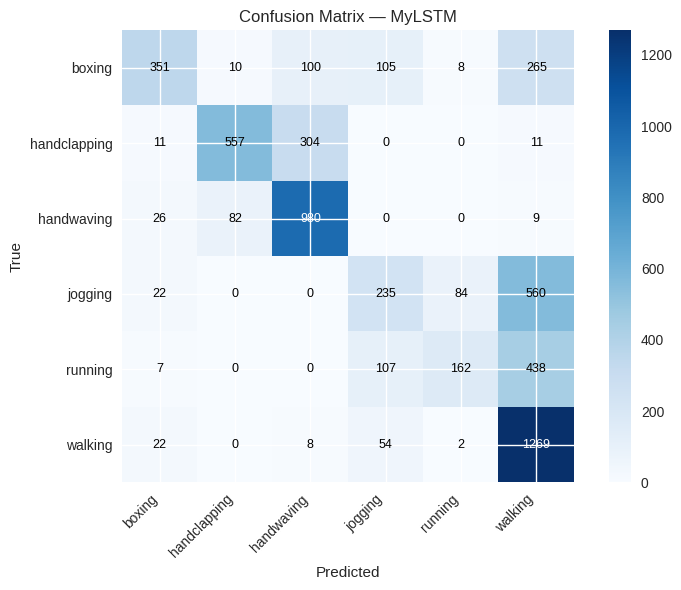

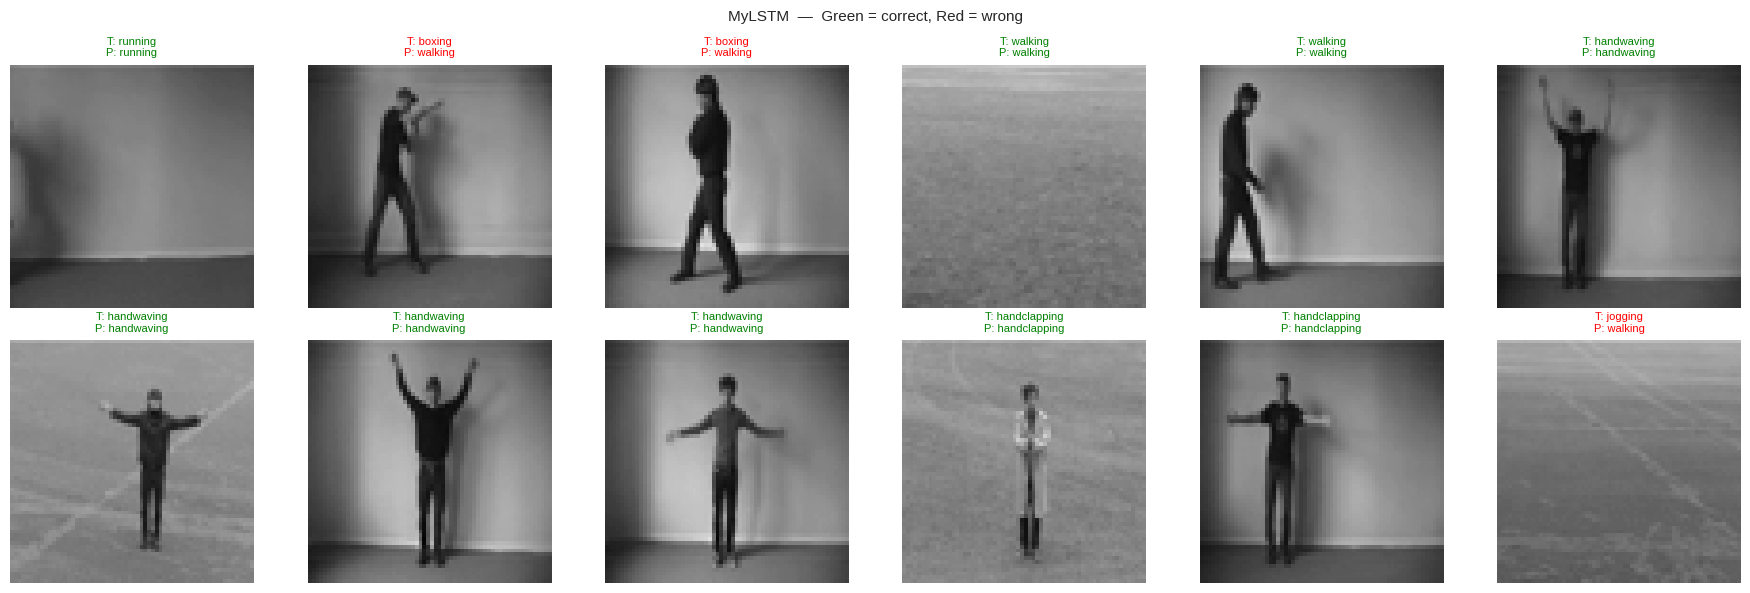


 ConvLSTM


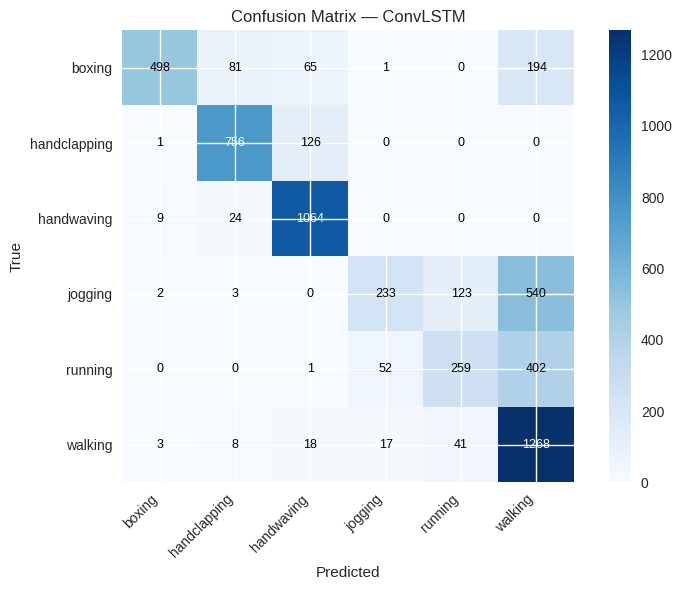

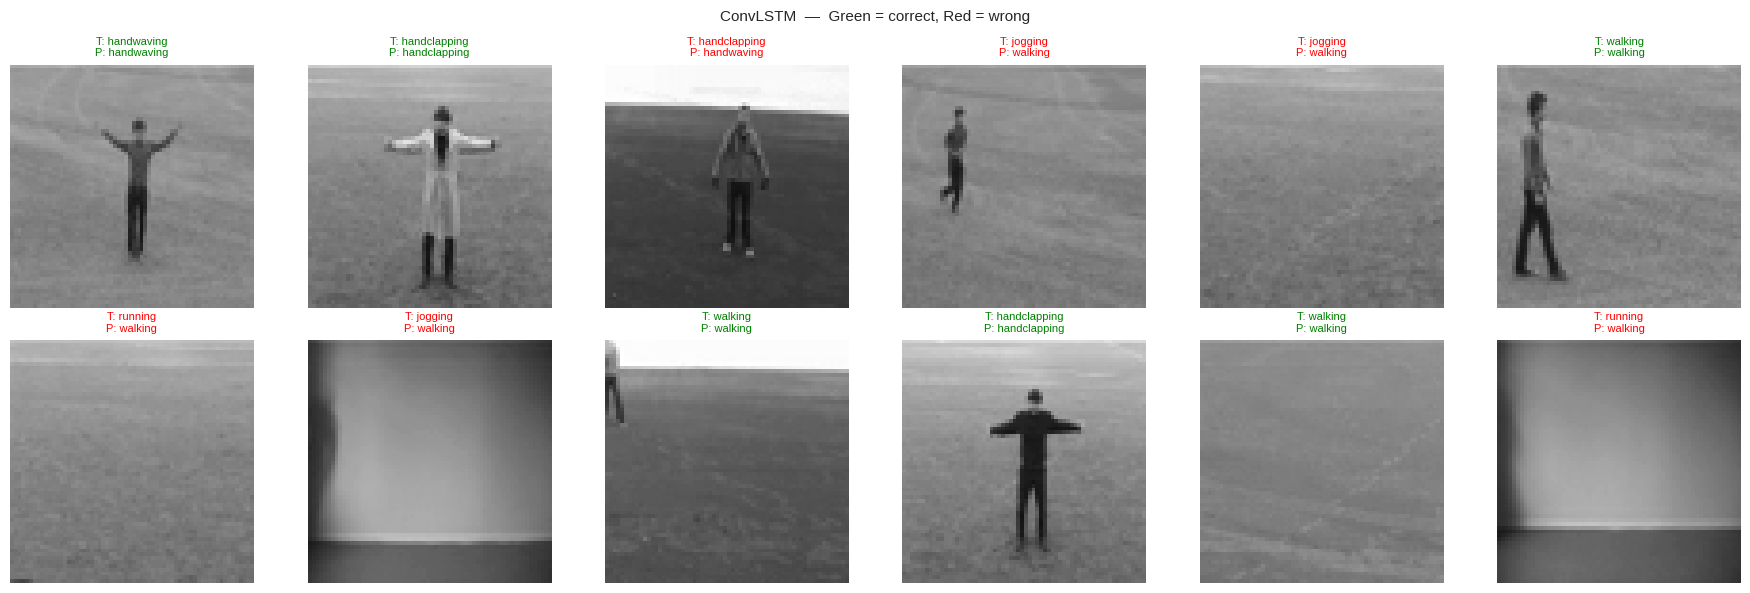

In [21]:
for name, r in results.items():
    print(f"\n{'='*40}\n {name}\n{'='*40}")
    plot_confusion_matrix(r["model"], test_loader, device, model_name=name)
    visualize_predictions(r["model"], test_dataset, device, n=12, model_name=name)

## Evaluation

*(Fill in after training — compare accuracy, training speed, parameter count, and discuss trade-offs between the 4 RNN variants. Reference the confusion matrices to identify which action classes are most commonly confused.)*